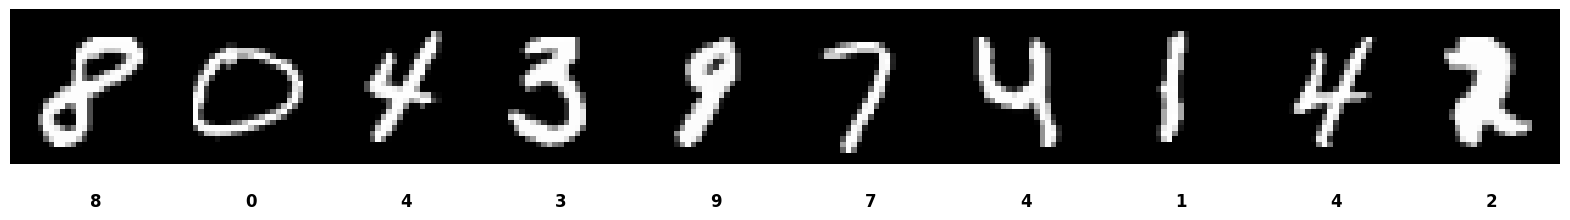

In [38]:
# 0. Import libraries
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

###################################
# Write your own code here #
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Input
from keras.utils import to_categorical
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
###################################

font = {'weight' : 'bold',
        'size'   : 12}
matplotlib.rc('font', **font)

# 1. Dataset
# 1.1 Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 1.2 Dataset examination
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

display_random_images(X_train, y_train)

In [39]:
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encoding pro cílovou proměnnou (10 tříd pro číslice 0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


model = Sequential()

model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

loss = None
optimizer = None
metrics = None
learning_rate = 0.0


learning_rate = 0.001
loss = 'categorical_crossentropy'
optimizer = Adam(learning_rate=learning_rate)
metrics = ['accuracy']

model.compile(
    loss=loss,
    optimizer=optimizer,
    metrics=metrics
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,634 (182.16 KB)

 Trainable params: 46,634 (182.16 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8809 - loss: 0.4178 - val_accuracy: 0.9565 - val_loss: 0.1641
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9532 - loss: 0.1582 - val_accuracy: 0.9733 - val_loss: 0.1031
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9647 - loss: 0.1185 - val_accuracy: 0.9784 - val_loss: 0.0811
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9705 - loss: 0.0989 - val_accuracy: 0.9800 - val_loss: 0.0732
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9729 - loss: 0.0891 - val_accuracy: 0.9802 - val_loss: 0.0694
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9753 - loss: 0.0803 - val_accuracy: 0.9813 - val_loss: 0.0658
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9779 - loss: 0.0734 - val_accuracy: 0.9823 - val_loss: 0.0616
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.9780 - loss: 0.0713 - 

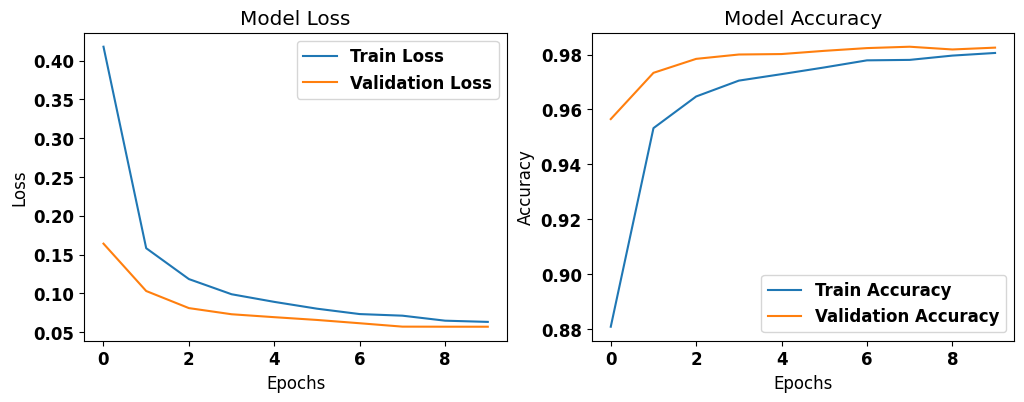

Test loss: 0.0485
Test accuracy: 98.46 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


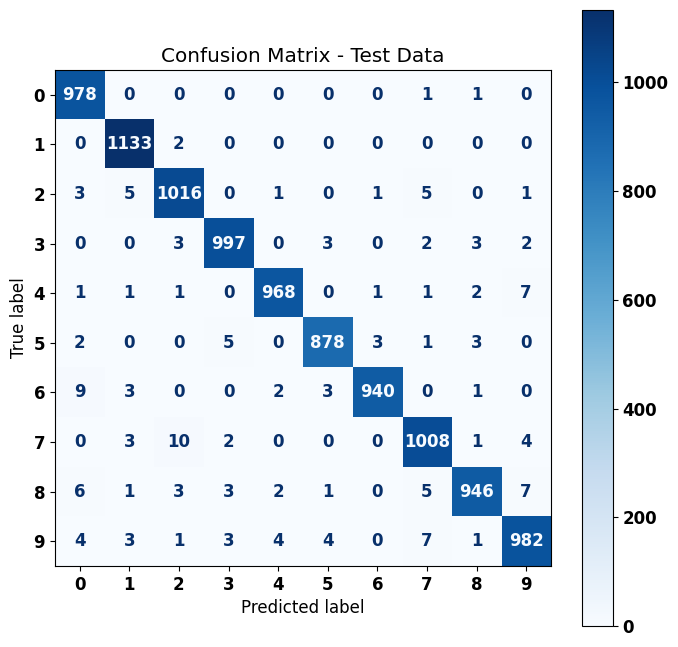

In [41]:


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]*100:.2f} %')

predictions = model.predict(X_test)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix - Test Data")
plt.show()

